In [4]:
# **❤️ Heart Disease ML Project**
<img src="https://i.postimg.cc/Vvbhnscg/Heart-Disease.png" width="700">

SyntaxError: invalid syntax (3411302975.py, line 2)

## **🧠 Problem Understanding**
- To build a machine learning model that predicts whether a patient has heart disease based on their medical features.

## **📊 Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## **📂 Load Dataset**

In [2]:
df=pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


## **🔍 Data Understanding**

In [7]:
df.shape

(1025, 14)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [6]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


##**📊 Exploratory Data Analysis (EDA)**

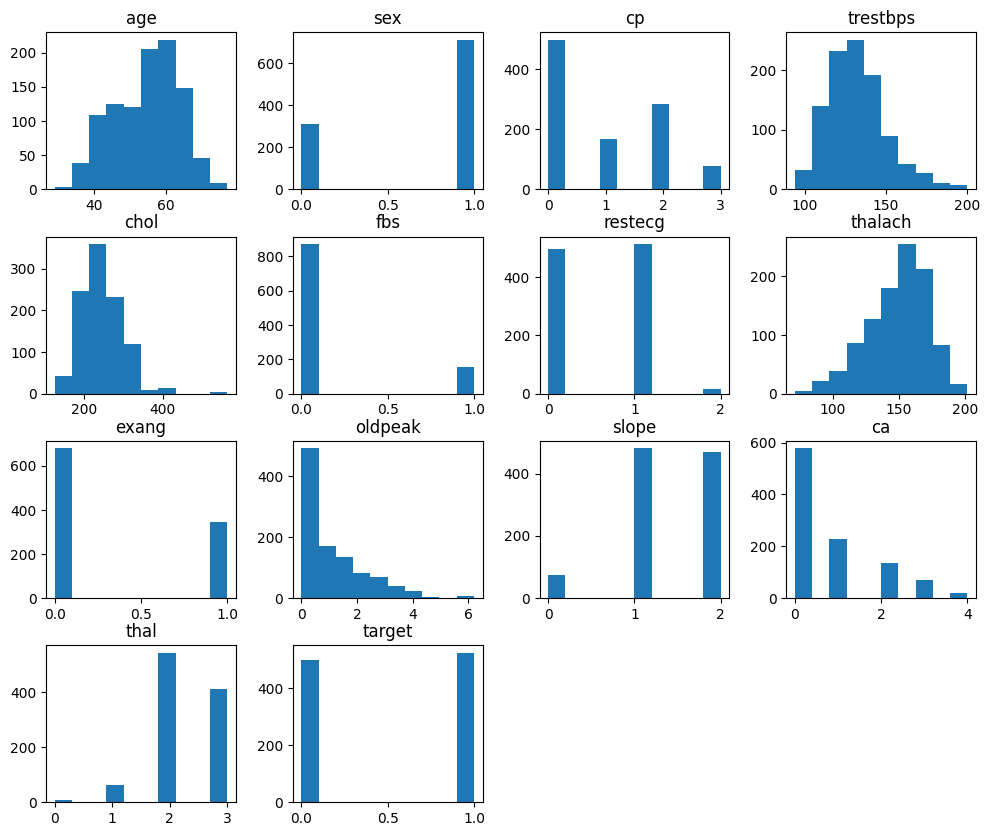

In [11]:
df.hist(
    figsize=(12,10),
    grid=False
    )
plt.show()

- Most features show a varied distribution, indicating diversity in patient data.
- Age is mostly concentrated between middle-aged and older individuals.
- Cholesterol and resting blood pressure show a wide spread, suggesting variation in health conditions.
- Some features like `fbs` and `exang` are binary and show imbalance in values.
- The target variable appears reasonably balanced, making it suitable for classification.

In [19]:
corr=df.corr()
corr

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


- Some features show a strong positive or negative correlation with the target variable, indicating their importance in predicting heart disease.
- Features like chest pain (`cp`), maximum heart rate (`thalach`), and number of vessels (`ca`) are likely to have a significant influence on the target.
- Certain features exhibit low correlation with the target, suggesting they may have less impact individually.
- There is some correlation between input features themselves, but no extreme multicollinearity is observed.
- Overall, the dataset contains meaningful relationships that can be effectively learned by machine learning models.

In [21]:
df.value_counts("target")

,count
target,
1,526
0,499


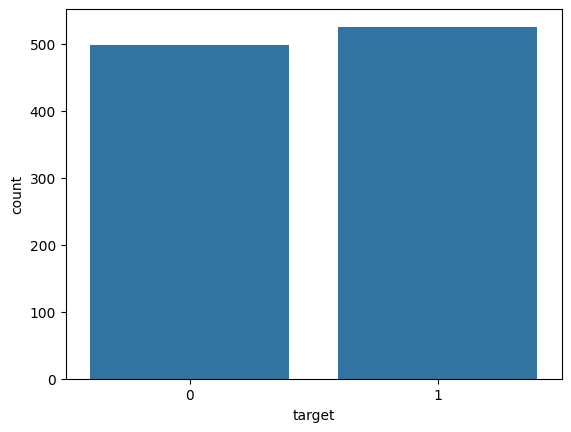

In [20]:
sns.countplot(
    data=df,
    x="target"
)
plt.show()

- The dataset shows a nearly equal distribution of patients with and without heart disease.
- There is no significant class imbalance, which is beneficial for training a reliable model.
- Both classes (0: No Disease, 1: Disease) are well represented.
- This balanced distribution allows the model to learn patterns for both classes effectively.

## **🎯Define Features & Target**

In [22]:
X=df.drop("target",axis=1)
y=df["target"]

In [23]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2


In [24]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
1020,1
1021,0
1022,0
1023,1


## **✂️ Train-Test Split**

In [25]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=14
)

In [26]:
X_train.shape

(820, 13)

In [27]:
X_test.shape

(205, 13)

In [28]:
y_train.shape

(820,)

In [29]:
y_test.shape

(205,)

## **🌳Train Baseline Model**

In [30]:
model=DecisionTreeClassifier(random_state=14)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
y_pred

array([1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 0])

## **📊 Evaluate Baseline Model**

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Recall: 1.0
Precision: 1.0
F1 Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       1.00      1.00      1.00       109

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [36]:
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[ 96   0]
 [  0 109]]


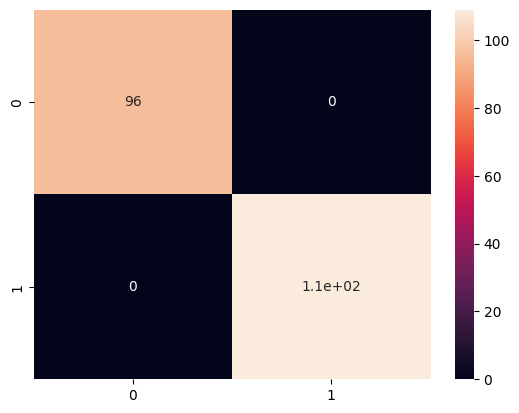

In [38]:
sns.heatmap(
    cm,
    annot=True
)
plt.show()

## **🔄 Cross Validation**

In [42]:
scores=cross_val_score(model,X,y,cv=5,scoring="recall")
for i in range(0,5):
  print(f'The score of fold{i+1} is {scores[i]*100}')
print("Average recall score : ",scores.mean()*100)

The score of fold1 is 100.0
The score of fold2 is 100.0
The score of fold3 is 100.0
The score of fold4 is 100.0
The score of fold5 is 100.0
Average recall score :  100.0


## **🔍 Hyperparameter Tuning (GridSearch)**

In [43]:
param_grid={
    "max_depth":[None,2,3,5,10],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

scoring={
    "accuracy":"accuracy",
    "recall":"recall",
    "precision":"precision",
    "f1":"f1"
}

grid=GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring,
    cv=5,
    n_jobs=-1,
    refit="recall"
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=14), n_jobs=-1,
             param_grid={'max_depth': [None, 2, 3, 5, 10],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             refit='recall',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

## **🏆 Best Model**

In [46]:
print("The best parameters : ",grid.best_params_)
print("\nThe best model : ",grid.best_estimator_)
print("\nThe best recall score : ",grid.best_score_)

print()
best_model=grid.best_estimator_
y_pred_gcv=best_model.predict(X_test)
y_pred_gcv

The best parameters :  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

The best model :  DecisionTreeClassifier(random_state=14)

The best recall score :  0.9856569133677567



array([1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 0])

##**📊 Final Evaluation**

In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred_gcv))
print("Precision:", precision_score(y_test, y_pred_gcv))
print("Recall:", recall_score(y_test, y_pred_gcv))
print("F1 Score:", f1_score(y_test, y_pred_gcv))

print("\nClassification Report:\n", classification_report(y_test, y_pred_gcv))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       1.00      1.00      1.00       109

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [71]:
cm=confusion_matrix(y_test,y_pred_gcv)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[ 96   0]
 [  0 109]]


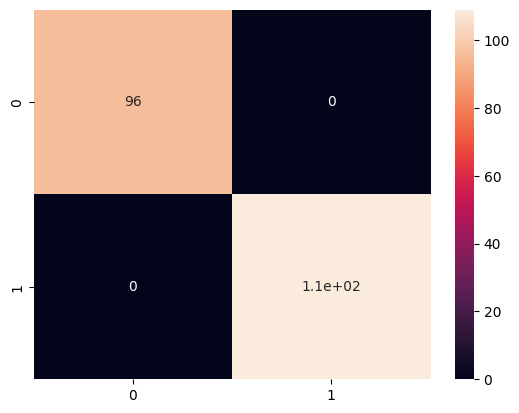

In [51]:
sns.heatmap(
    cm,
    annot=True
)
plt.show()

##**🌳 Decision Tree Visualization**

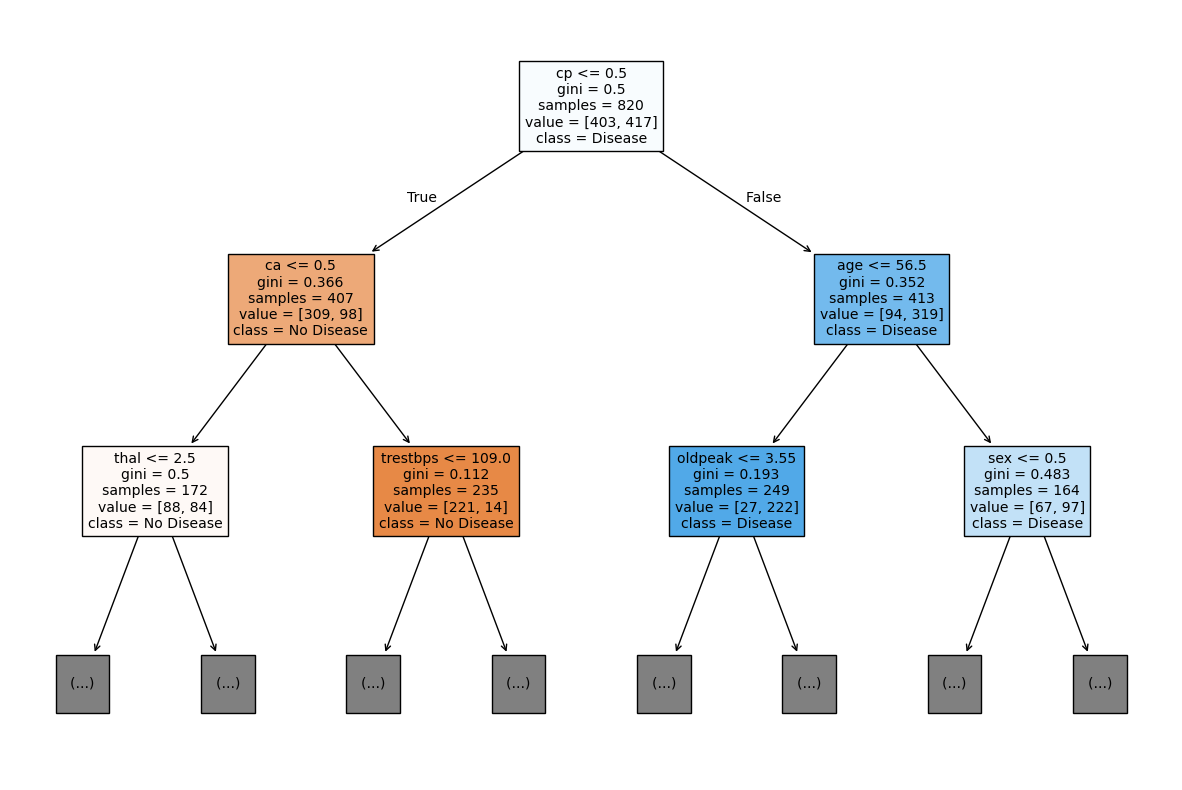

In [68]:
plt.figure(figsize=(15,10))
plot_tree(
    best_model,
    max_depth=2,
    feature_names=X.columns,
    class_names=["No Disease","Disease"],
    filled=True
)
plt.show()

## 📈 Feature Importance

In [69]:
importance = pd.Series(best_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
cp,0.289648
ca,0.130395
chol,0.112156
age,0.098386
oldpeak,0.080554
thal,0.078325
trestbps,0.049797
thalach,0.047703
sex,0.038000
slope,0.026841
